In [1]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from tabulate import tabulate
import json
from IPython.display import HTML, display
import time
import ipywidgets as widgets
import ipywidgets as w
from IPython.display import Javascript

np.random.seed(999)


from bstpp.main import Hawkes_Model

JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [2]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

## Loadding full 311 dataset

In [8]:
## Got updated data from 311 team on 8/20/2025

file_paths = {
    "ppr311_18":"data/311/PPR3112016_to_2019/PPR311DumpingDataforDDDI_CY2018.csv",
    "ppr311_19":"data/311/PPR3112016_to_2019/PPR311DumpingDataforDDDI_CY2019.csv",
    "ppr311_20":"data/311/PPR3112020_to_2022/PPR311DumpingDataforDDDI_CY2020.csv",
    "ppr311_21":"data/311/PPR3112020_to_2022/PPR311DumpingDataforDDDI_CY2021.csv",
    "ppr311_22":"data/311/PPR3112020_to_2022/PPR311DumpingDataforDDDI_CY2022.csv",
    "ppr311_23":"data/311/PPR3112023_to_2025/PPR311DumpingDataforDDDI_CY2023.csv",
    "ppr311_24":"data/311/PPR3112023_to_2025/PPR311DumpingDataforDDDI_CY2024.csv",
    "ppr311_25":"data/311/PPR3112023_to_2025/PPR311DumpingDataforDDDI_CY2025.csv",
    "ppr311_25_aug_dec":"data/311/PPR311DumpingDataforDDDI_Aug2025toDec2025.csv"
}

rename_map = {
        "Date/Time Opened" :"start_time",
        "Date/Time Closed" : "close_time",
        "Service Request Number" : "request_id",
        "Service Request Type" : "type",
        "Department" : "department",
        "Address/Intersection" : "address",
        "ZipCode" : "zipcode",
        "Status" : "status",
        "Problem Category" : "problem_category",
        "Problem" : "problem",
        "Location Type" : "location_type",
        "Park District" : "park_district",
        "Large Crew&Heavy Machinery To Clean Up?" : "large_crew",
        "Type of Materials" : "material_type",
        "Condition of Materials" : "material_condition",
        "Description" : "description",
        "Centerline (Latitude)" : "lat",
        "Centerline (Longitude)" : "lon",
        "Case ID" : "case_id",
        "Parent Case ID" : "parent_case_id",
        "Mobile App Photos" : "media_url"
}

for var_name, path in file_paths.items():
    with open(path, encoding="utf-8", errors="replace") as f:
        df = pd.read_csv(f).rename(columns=rename_map)
        
        # ==== add year column ====
        year = int(var_name.split("_")[1]) + 2000  # e.g., "ppr311_21" → 21 → 2021
        df["year"] = year

        # ==== convert time columns to yyyy/mm/dd HH:MM ====
        for col in ["start_time", "close_time"]:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
                df[col] = df[col].dt.strftime("%Y/%m/%d %H:%M")

        # ==== clean coords ====
        df[["lon", "lat"]] = df[["lon", "lat"]].apply(pd.to_numeric, errors="coerce")
        df.loc[(df["lon"] == 0) & (df["lat"] == 0), ["lon", "lat"]] = np.nan
        deg_mask = df["lon"].between(-76, -74) & df["lat"].between(39, 41)
        df = df[deg_mask].dropna(subset=["lon", "lat"])

        # ==== build geometry ====
        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df["lon"], df["lat"]),
            crs=4326
        ).to_crs(26918)

        globals()[var_name] = gdf


/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_19609/3356488702.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_19609/3356488702.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_19609/3356488702.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/nr/q7sysy9j07x_5smd2gfx3j38

In [11]:
ppr311_25_aug_dec['start_time'].min()

'2025/08/01 03:34'

In [12]:
## Build full 2025 dataset without double-counting Aug–Dec
cutoff_str = "2025/08/01 00:00"

# Keep only records strictly before 2025-08-01 in the original 2025 file
ppr311_25 = ppr311_25[ppr311_25["start_time"] < cutoff_str].copy()

# Combine the trimmed 2025 data with the updated Aug–Dec file
ppr311_25_full = pd.concat(
    [ppr311_25, ppr311_25_aug_dec],
    ignore_index=True
).sort_values("start_time").reset_index(drop=True)

In [13]:
## concact 2021, 2022, 2023, and 2024 data
illegal_dumping = pd.concat([
    ppr311_21,
    ppr311_22,
    ppr311_23,
    ppr311_24,
    ppr311_25_full
])
#illegal_dumping = illegal_dumping_23
total_days = 365 * 5

## Adding filtering for analysis

In [14]:
## filter all illegal dumping cases by `type`
illegal_dumping_ppr = illegal_dumping[illegal_dumping['type'] == 'Illegal Dumping']

print(illegal_dumping_ppr.shape)


(131575, 23)


In [15]:
## load manually selected case id
picked_yes = pd.read_csv('output/picked_yes.csv', header=None)
picked_yes.columns = ['request_id']
# save back to csv
#picked_yes.to_csv('output/picked_yes.csv', index=False)

# Convert request_id to string in both DataFrames
picked_yes['request_id'] = picked_yes['request_id'].astype(str)
illegal_dumping['request_id'] = illegal_dumping['request_id'].astype(str)

## merge with ppr311 data
illegal_dumping_yes = illegal_dumping.merge(picked_yes, on='request_id', how='right')

## concact with illegal dumping data
illegal_dumping_full = pd.concat([illegal_dumping_ppr, illegal_dumping_yes], ignore_index=True)


In [16]:
## load pending-confirmed cases
pending_confirmed = pd.read_csv('output/dfv_CRT.csv')
pending_confirmed = pending_confirmed[pending_confirmed['confirm'] == 1][['request_id']]

# Convert request_id to string in both DataFrames
pending_confirmed['request_id'] = pending_confirmed['request_id'].astype(str)

## merge with ppr311 data
illegal_dumping_confirmed = illegal_dumping.merge(pending_confirmed, on='request_id', how='right')

## concact with illegal dumping data
illegal_dumping_full = pd.concat([illegal_dumping_full, illegal_dumping_confirmed], ignore_index=True)

In [17]:
## export to GeoJSON
illegal_dumping_full.to_file('output/illegal_dumping_full.geojson', driver='GeoJSON')

## Descriptive analysis

In [5]:
## print total number of observations
print(illegal_dumping.shape)

(133365, 23)


In [6]:
illegal_dumping.columns

Index(['start_time', 'close_time', 'request_id', 'type', 'department',
       'address', 'zipcode', 'status', 'problem_category', 'problem',
       'location_type', 'park_district', 'large_crew', 'material_type',
       'material_condition', 'description', 'lat', 'lon', 'case_id',
       'parent_case_id', 'media_url', 'year', 'geometry'],
      dtype='object')

In [7]:
## print the counts if type
counts = illegal_dumping['type'].value_counts(dropna=False)
counts_df = counts.reset_index()
counts_df.columns = ['Type', 'Count']
print(tabulate(counts_df, headers='keys', tablefmt='pretty'))

+---+------------------------+--------+
|   |          Type          | Count  |
+---+------------------------+--------+
| 0 |    Illegal Dumping     | 127230 |
| 1 |  Grounds Maintenance   |  4793  |
| 2 | Janitorial Maintenance |  1306  |
| 3 | Mechanical Maintenance |   16   |
| 4 |       Emergency        |   6    |
| 5 |    Tree Maintenance    |   5    |
| 6 |        Grounds         |   4    |
| 7 |      Street Trees      |   3    |
| 8 |    Other (Streets)     |   1    |
| 9 |      Emergencies       |   1    |
+---+------------------------+--------+


In [9]:
## convert to gpd
illegal_dumping_gpd = gpd.GeoDataFrame(
    illegal_dumping,
    geometry=gpd.points_from_xy(illegal_dumping['lon'], illegal_dumping['lat']),
    crs="EPSG:4326"   # WGS84
)

# convert to EPSG:26918
illegal_dumping_gpd = illegal_dumping_gpd.to_crs(epsg=26918)

## Visualizing report recurrence

In [10]:
## drop invalid geometry: no invalid geometry in the dataset
illegal_dumping_gpd = illegal_dumping_gpd[illegal_dumping_gpd.geometry.notnull()].copy()
illegal_dumping_gpd.shape

(133365, 23)

### Computing response and report time

In [11]:
## location aggregation
# round to nearest multiple of 10
illegal_dumping_gpd['x_round'] = (illegal_dumping_gpd.geometry.x / 10).round() * 10
illegal_dumping_gpd['y_round'] = (illegal_dumping_gpd.geometry.y / 10).round() * 10

# nre xy coords column
illegal_dumping_gpd['xy_round'] = list(zip(illegal_dumping_gpd['x_round'], illegal_dumping_gpd['y_round']))

# drop x_round and y_round
illegal_dumping_gpd = illegal_dumping_gpd.drop(columns=['x_round', 'y_round'])

In [12]:
## transform time var to datetime
illegal_dumping_gpd['start_time'] = pd.to_datetime(illegal_dumping_gpd['start_time'])
illegal_dumping_gpd['close_time'] = pd.to_datetime(illegal_dumping_gpd['close_time'])


## computing response time: between closed_date and requested_date
illegal_dumping_gpd['response_time'] = illegal_dumping_gpd['close_time'] - illegal_dumping_gpd['start_time']

In [13]:
# Step 1: Ensure datetime columns
df = illegal_dumping_gpd.copy()
df['start_time'] = pd.to_datetime(df['start_time'])
df['close_time'] = pd.to_datetime(df['close_time'])

# Step 2: Prepare all potential (xy_round, prev_closed, start_time) combinations
df_left = df[['xy_round', 'start_time']].copy()
df_right = df[['xy_round', 'close_time']].copy().rename(columns={'close_time': 'prev_closed'})

# Step 3: Cross join within each xy_round, and filter prev_closed < start_time
df_prev = (
    df_left.merge(df_right, on='xy_round', how='left')
           .query("prev_closed < start_time")
)

# Step 4: For each (xy_round, start_time), pick the latest prev_closed
df_prev = (
    df_prev.sort_values(['xy_round', 'start_time', 'prev_closed'])
           .drop_duplicates(['xy_round', 'start_time'], keep='last')
)

# Step 5: Merge back to original df to assign prev_closed
df = df.merge(df_prev, on=['xy_round', 'start_time'], how='left')

# Step 6: Avoid self-matches (if any)
df.loc[df['prev_closed'] == df['close_time'], 'prev_closed'] = pd.NaT

# Step 7: Find next_request after prev_closed (your original logic)
future_requests = (
    df[['xy_round', 'start_time', 'prev_closed']]
    .merge(df[['xy_round', 'start_time']].rename(columns={'start_time': 'next_request'}),
           on='xy_round', how='left')
)

# Only keep future requests after this row’s prev_closed
future_requests = future_requests[future_requests['next_request'] > future_requests['prev_closed']]

# Sort and keep the first next request per (xy_round, prev_closed)
future_requests = (
    future_requests.sort_values('next_request')
                   .groupby(['xy_round', 'prev_closed'], as_index=False)
                   .first()
)

# Step 8: Merge back next_request to main df
df = df.merge(future_requests[['xy_round', 'prev_closed', 'next_request']],
              on=['xy_round', 'prev_closed'], how='left')

# Step 9: Calculate deltas
df['delta_t'] = df['next_request'] - df['prev_closed']
df['delta_t_days'] = df['delta_t'].dt.total_seconds() / (24 * 3600)


Text(0.5, 1.0, 'Histogram of delta_t_days (log-scaled count)')

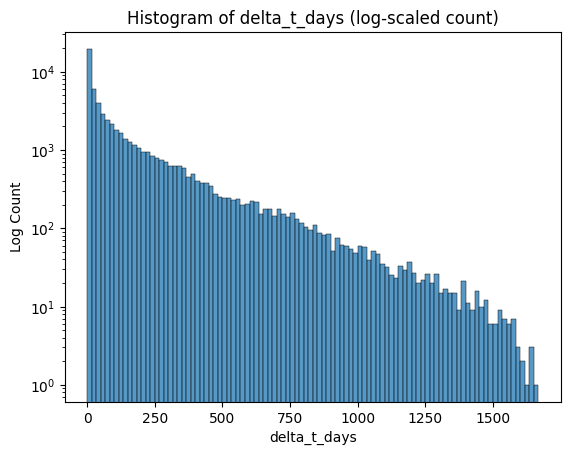

In [14]:
## histogram
sns.histplot(x=df['delta_t_days'], bins=100)
plt.yscale('log')
plt.xlabel("delta_t_days")
plt.ylabel("Log Count")
plt.title("Histogram of delta_t_days (log-scaled count)")

<Axes: >

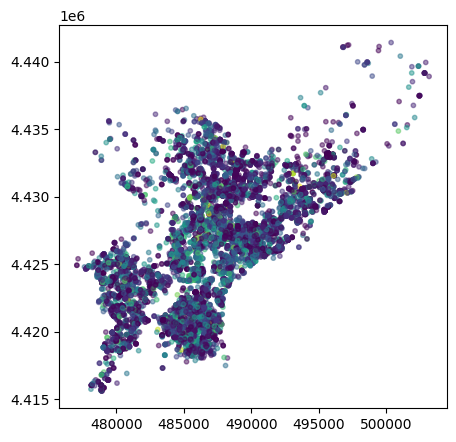

In [15]:
## spatial distribution
fig, ax = plt.subplots(figsize=(5, 5))
df_map = df.copy()
df_map[(df_map['start_time'] >= '2022-01-01') & (df_map['close_time'] <= '2023-01-01')].plot(ax=ax, column = 'delta_t_days',cmap = 'viridis', markersize=10, alpha=0.5)


### Case start & close time pairs: without merging parent_child cases

In [16]:
# Sort by location and time
df = df.sort_values(['xy_round', 'start_time'])

# Function to calculate accumulated count between cleanups for each location
def accumulate_counts(group):
    group = group.copy()
    count = 0
    last_close = None
    
    for i, row in group.iterrows():
        # If we see a cleanup date later than the last one, reset
        if pd.notnull(row['prev_closed']) and (last_close is None or row['prev_closed'] > last_close):
            last_close = row['prev_closed']
            count = 0
        count += 1
        group.at[i, 'accum_count'] = count
    return group

# Apply per location
df = df.groupby('xy_round', group_keys=False).apply(accumulate_counts)

# Sum accumulation across all locations per day
daily_counts = (
    df.groupby('start_time', as_index=False)['accum_count']
      .sum()
)

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_44805/3126468743.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('xy_round', group_keys=False).apply(accumulate_counts)


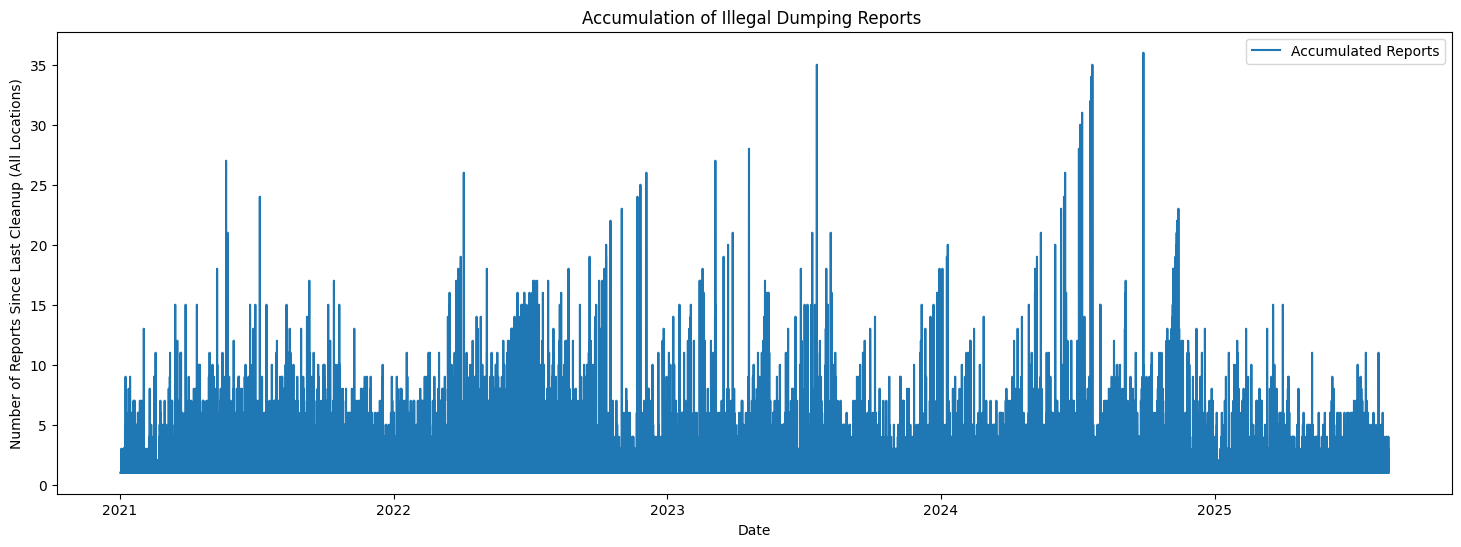

In [17]:
# Plot zoomed-in period
plt.figure(figsize=(18,6))
plt.plot(daily_counts['start_time'], daily_counts['accum_count'], label='Accumulated Reports')
plt.xlabel('Date')
plt.ylabel('Number of Reports Since Last Cleanup (All Locations)')
plt.title('Accumulation of Illegal Dumping Reports ')
plt.legend()
plt.show()

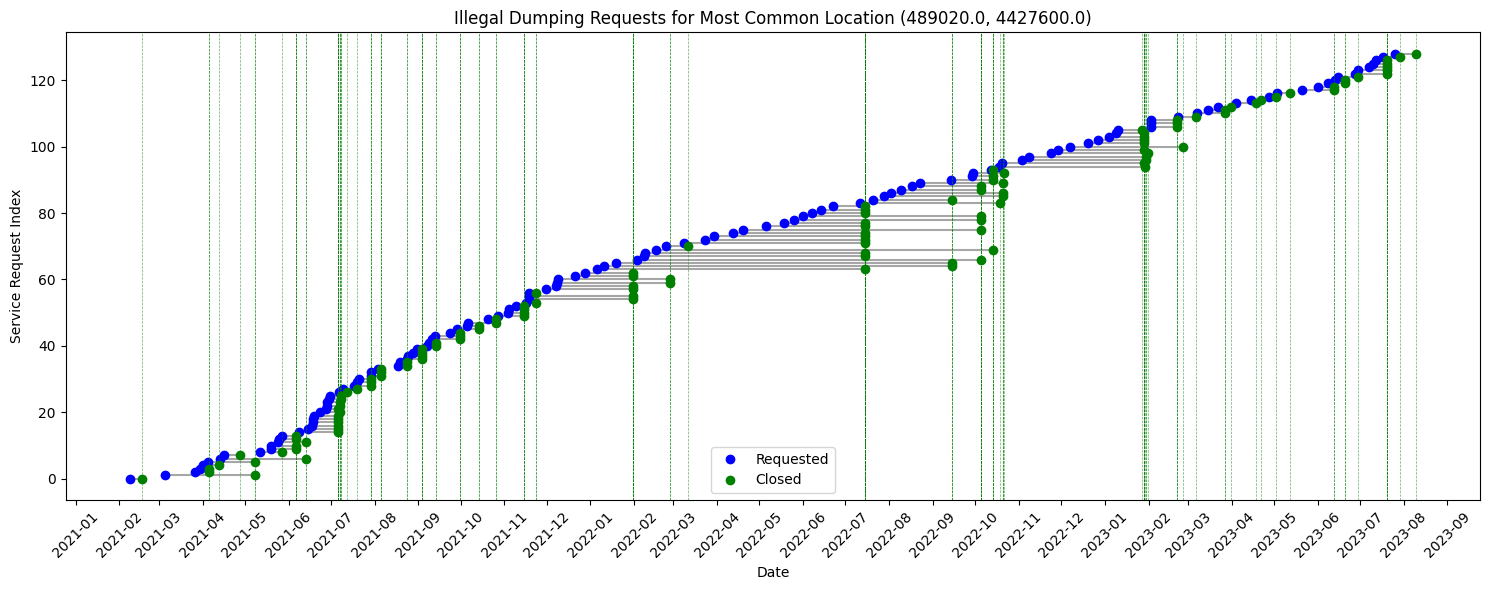

In [18]:
# Filter within date range
start_date = pd.to_datetime("2021-01-01")
end_date = pd.to_datetime("2023-08-01")
df_filtered = df[(df['start_time'] >= start_date) & (df['start_time'] <= end_date)]

# Find the most frequent xy_round
most_common_xy = df_filtered['xy_round'].mode().iloc[0]

# Keep only rows with the most frequent xy_round
df_xy = df_filtered[df_filtered['xy_round'] == most_common_xy].copy()

# Sort by start_time for plotting
df_xy = df_xy.sort_values('start_time').reset_index(drop=True)

# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Dumbbell lines
ax.hlines(y=df_xy.index, xmin=df_xy['start_time'], xmax=df_xy['close_time'], color='gray', alpha=0.7)

# Start (start_time) dots
ax.plot(df_xy['start_time'], df_xy.index, "o", label="Requested", color='blue')

# End (close_time) dots
ax.plot(df_xy['close_time'], df_xy.index, "o", label="Closed", color='green')

# Add vertical lines at each close_time
for date in df_xy['close_time']:
    ax.axvline(date, color='green', linestyle='--', linewidth=0.5, alpha=0.6)

# Format x-axis as dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# Labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Service Request Index")
ax.set_title(f"Illegal Dumping Requests for Most Common Location {most_common_xy}")
ax.legend()
plt.tight_layout()


plt.savefig('output/dumbell_most.png', dpi=500, bbox_inches='tight')
plt.show()

### Checking points in the parks

In [19]:
## load ppr box data
all_boxes_gdf = gpd.read_file('output/all_boxes_gdf.geojson')
all_boxes_gdf = all_boxes_gdf.to_crs(26918)
## load parks data
all_parks_gdf = gpd.read_file('output/all_parks_gdf.geojson')
all_parks_gdf = all_parks_gdf.to_crs(26918)

In [20]:
## process parks dataset
all_parks_gdf['park'] = all_parks_gdf['PARENT_NAME'].str.lower().map(lambda name: 
    'cobbs_creek' if 'cobbs creek' in name else
    'mifflin' if 'mifflin' in name else
    'tacony_creek' if 'tacony creek' in name else
    'fairmount' if 'fairmount' in name else
    None
)

In [27]:
# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping_gpd.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: add park name
illegal_dumping_in_park = gpd.sjoin(
    illegal_dumping_in_park,
    all_parks_gdf[['park', 'geometry']],
    how = "left",
    predicate="within"
)


park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == "tacony_box"]
park_points.shape

(5020, 28)

In [ ]:
## print the counts if type
counts = illegal_dumping_in_park['park'].value_counts(dropna=False)
counts_park = counts.reset_index()
counts_park.columns = ['Park', 'Count']
print(tabulate(counts_park, headers='keys', tablefmt='pretty'))

+---+--------------+-------+
|   |     Park     | Count |
+---+--------------+-------+
| 0 |     nan      | 27697 |
| 1 |  fairmount   |  436  |
| 2 | tacony_creek |  71   |
| 3 |   mifflin    |  69   |
| 4 | cobbs_creek  |  21   |
+---+--------------+-------+


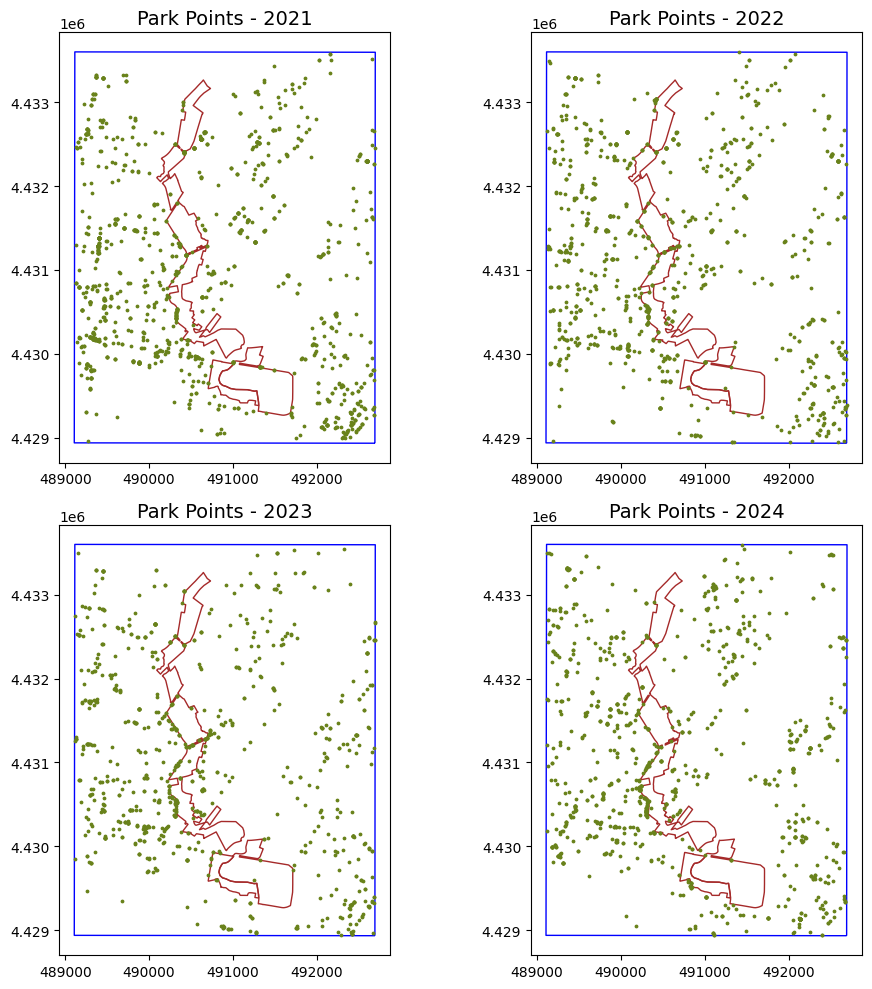

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
years = [2021, 2022, 2023, 2024]

for ax, yr in zip(axes.flatten(), years):
    ax.set_title(f"Park Points - {yr}", fontsize=14)

    # --- plot park boundary ---
    all_boxes_gdf[all_boxes_gdf['PARKNAME'] == "tacony_box"].plot(
        ax=ax, edgecolor="blue", color="none"
    )
    all_parks_gdf[all_parks_gdf['park'] == "tacony_creek"].plot(
        ax=ax, edgecolor="brown", color="none"
    )

    # --- plot points for the given year ---
    park_points[park_points['year'] == yr].plot(
        ax=ax, color="#69821b", markersize=3
    )

plt.tight_layout()
plt.savefig('output/points_in_park_tacony.png', dpi=500, bbox_inches='tight')
plt.show()

## Filtering illegal dumping cases 

In [22]:
## filter out the non-illegal dumping cases by department and problem type
illegal_dumping_ppr = illegal_dumping_gpd[
    (illegal_dumping_gpd['department'] == "Parks & Recreation") &
    (~illegal_dumping_gpd['problem'].str.contains('Trash|Litter', case=False, na=False))
]

illegal_dumping_ppr.shape

(3360, 25)

In [24]:
## train an classifier

# --- filter data (edit pattern/cols as needed) ---
pattern = r"trash|litter|waste|garbage|debris|dump|refuse"
dfv = (illegal_dumping_ppr.loc[
         illegal_dumping_ppr["description"].str.contains(pattern, case=False, na=False),
         ["request_id","type","status","description"]
      ].fillna("").reset_index(drop=True))

picked_yes = []
picked_pending = []
i = 0

out = w.Output()
status = w.HTML()

def state_of(rid:str):
    if rid in picked_yes: return "YES"
    if rid in picked_pending: return "PENDING"
    return "unlabeled"

def render():
    out.clear_output()
    if dfv.empty:
        with out: print("No rows to review."); status.value = ""
        return
    row = dfv.iloc[i]; rid = str(row.request_id)
    with out:
        display(HTML(
            f"<b>{i+1}/{len(dfv)}</b> &nbsp; "
            f"<b>request_id:</b> {rid} &nbsp; "
            f"<b>type:</b> {row.type} &nbsp; "
            f"<b>status:</b> {row.status}<br><br>"
            f"<div style='white-space:pre-wrap;border:1px solid #ddd;padding:8px;border-radius:6px;'>"
            f"{row.description}</div>"
        ))
    st = state_of(rid)
    status.value = (
        f"Yes: <b>{len(picked_yes)}</b> | Pending: <b>{len(picked_pending)}</b> "
        f"| Current: <b>{'<span style=color:green>YES</span>' if st=='YES' else ('<span style=color:#d27700>PENDING</span>' if st=='PENDING' else 'unlabeled')}</b>"
    )

def mark_yes(_):
    rid = str(dfv.iloc[i].request_id)
    if rid in picked_pending: picked_pending.remove(rid)
    if rid not in picked_yes: picked_yes.append(rid)
    on_next(_)

def mark_pending(_):
    rid = str(dfv.iloc[i].request_id)
    if rid in picked_yes: picked_yes.remove(rid)
    if rid not in picked_pending: picked_pending.append(rid)
    on_next(_)

def remove_from_yes(_):
    rid = str(dfv.iloc[i].request_id)
    if rid in picked_yes: picked_yes.remove(rid)
    render()

def on_prev(_):
    global i; i = max(0, i-1); render()

def on_next(_):
    global i; i = min(len(dfv)-1, i+1); render()

# buttons
btn_prev    = w.Button(description="← Prev")
btn_yes     = w.Button(description="Yes", button_style="success")
btn_pending = w.Button(description="Pending", button_style="warning")
btn_remove  = w.Button(description="Remove (from Yes)", button_style="danger")
btn_next    = w.Button(description="Next →")

btn_prev.on_click(on_prev)
btn_yes.on_click(mark_yes)
btn_pending.on_click(mark_pending)
btn_remove.on_click(remove_from_yes)
btn_next.on_click(on_next)

display(w.HBox([btn_prev, btn_yes, btn_pending, btn_remove, btn_next]), status, out)
render()

# Results:
# picked_yes       -> confirmed positives
# picked_pending   -> needs review later


HTML(value='')

Output()

In [25]:
len(picked_yes)

351

In [ ]:
## export the data to csv
# import csv
# with open("output/picked_yes.csv", "w", newline="") as f:
#     writer = csv.writer(f)
#     for item in picked_yes:
#         writer.writerow([item]) 


# with open("output/picked_pending.csv", "w", newline="") as f:
#     writer = csv.writer(f)
#     for item in picked_pending:
#         writer.writerow([item]) 
